**Company**: FreshMart Groceries, a mid-sized regional supermarket chain.

**The Problem**: FreshMart's online shopping platform is functional but lacks intelligence. The "Customers Also Bought" recommendations are generic and not personalized, leading to a low cross-selling conversion rate. Marketing campaigns are broad (e.g., "Weekly Dairy Sale") and not targeted to specific customer buying patterns. Management has identified that the average online order value has plateaued, and they are failing to capitalize on the natural affinities between products that their in-store customers discover visually.

**Business Goals**:

Increase Average Order Value (AOV): Encourage customers to add complementary items to their cart.

Improve Customer Experience: Provide smart, relevant product recommendations that feel helpful, not random.

Optimize Marketing Efforts: Create targeted promotional bundles and personalized digital coupons.

Inform Inventory & Placement: Understand product affinities to optimize shelf placement in physical stores and category organization online.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [3]:
orders = pd.read_csv('orders.csv')
order_products_prior = pd.read_csv('order_products__prior.csv')
products = pd.read_csv('products.csv')
departments = pd.read_csv('departments.csv')
aisles = pd.read_csv('aisles.csv')

print("Dataset shapes:")
print(f"Orders: {orders.shape}")
print(f"Order Products Prior: {order_products_prior.shape}")
print(f"Products: {products.shape}")
print(f"Departments: {departments.shape}")
print(f"Aisles: {aisles.shape}")

# Display basic information
print("\nFirst few rows of each dataset:")
print("Orders:")
print(orders.head())
print("\nOrder Products Prior:")
print(order_products_prior.head())
print("\nProducts:")
print(products.head())

Dataset shapes:
Orders: (807445, 7)
Order Products Prior: (1530356, 4)
Products: (49688, 4)
Departments: (21, 2)
Aisles: (134, 2)

First few rows of each dataset:
Orders:
   order_id  user_id eval_set  order_number  order_dow  order_hour_of_day  \
0   2539329        1    prior             1          2                  8   
1   2398795        1    prior             2          3                  7   
2    473747        1    prior             3          3                 12   
3   2254736        1    prior             4          4                  7   
4    431534        1    prior             5          4                 15   

   days_since_prior_order  
0                     NaN  
1                    15.0  
2                    21.0  
3                    29.0  
4                    28.0  

Order Products Prior:
   order_id  product_id  add_to_cart_order  reordered
0         2       33120                1.0        1.0
1         2       28985                2.0        1.0
2         2  

In [4]:
# Merge order products with product information
order_details = order_products_prior.merge(products, on='product_id', how='left')
order_details = order_details.merge(departments, on='department_id', how='left')
order_details = order_details.merge(aisles, on='aisle_id', how='left')

# Merge with order information
full_data = order_details.merge(orders, on='order_id', how='left')

print(f"Final merged dataset shape: {full_data.shape}")
print(f"Columns: {full_data.columns.tolist()}")

# Check for missing values
print("\nMissing values in each column:")
print(full_data.isnull().sum())

# Sample the data for manageable processing (using 10% of data for demonstration)
sample_orders = orders.sample(frac=0.1, random_state=42)
sample_data = full_data[full_data['order_id'].isin(sample_orders['order_id'])]

print(f"Sample data shape: {sample_data.shape}")

Final merged dataset shape: (1530356, 15)
Columns: ['order_id', 'product_id', 'add_to_cart_order', 'reordered', 'product_name', 'aisle_id', 'department_id', 'department', 'aisle', 'user_id', 'eval_set', 'order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_order']

Missing values in each column:
order_id                        0
product_id                      0
add_to_cart_order               1
reordered                       1
product_name                    0
aisle_id                        0
department_id                   0
department                      0
aisle                           0
user_id                   1169269
eval_set                  1169269
order_number              1169269
order_dow                 1169269
order_hour_of_day         1169269
days_since_prior_order    1192399
dtype: int64
Sample data shape: (37163, 15)


Basic Statistics:
Number of unique customers: 3383
Number of unique products: 10025
Number of transactions: 3635
Time period: 1.0 to 99.0


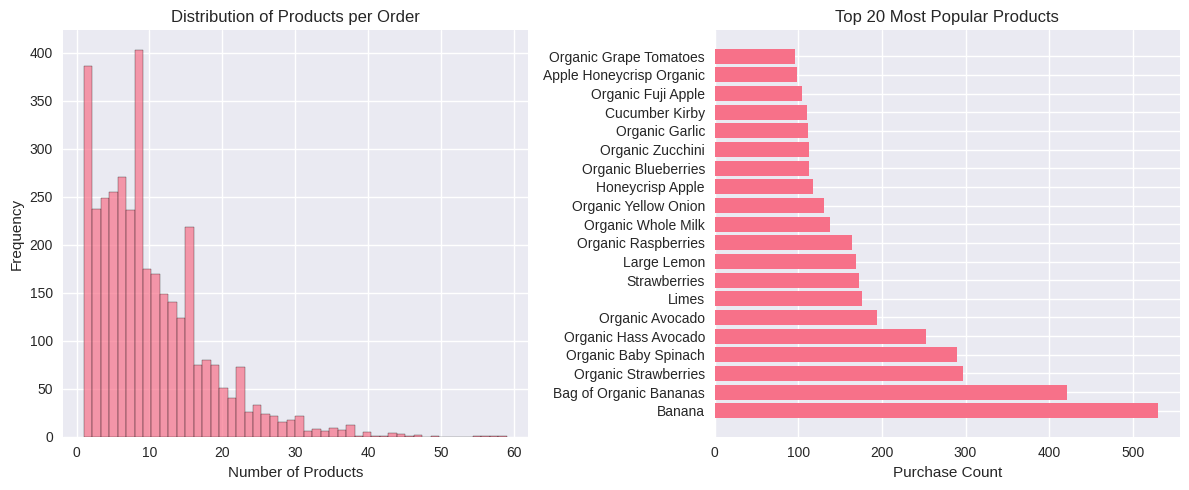

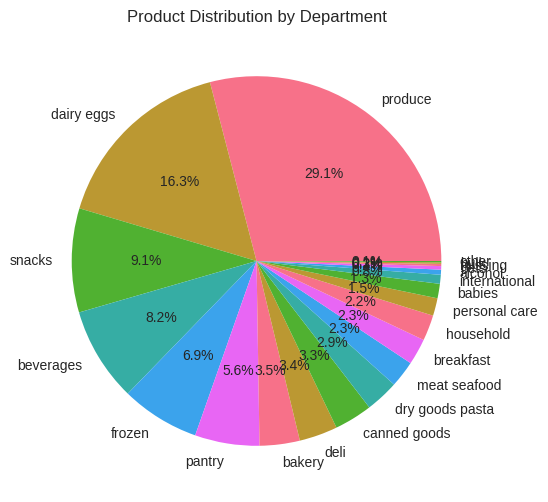

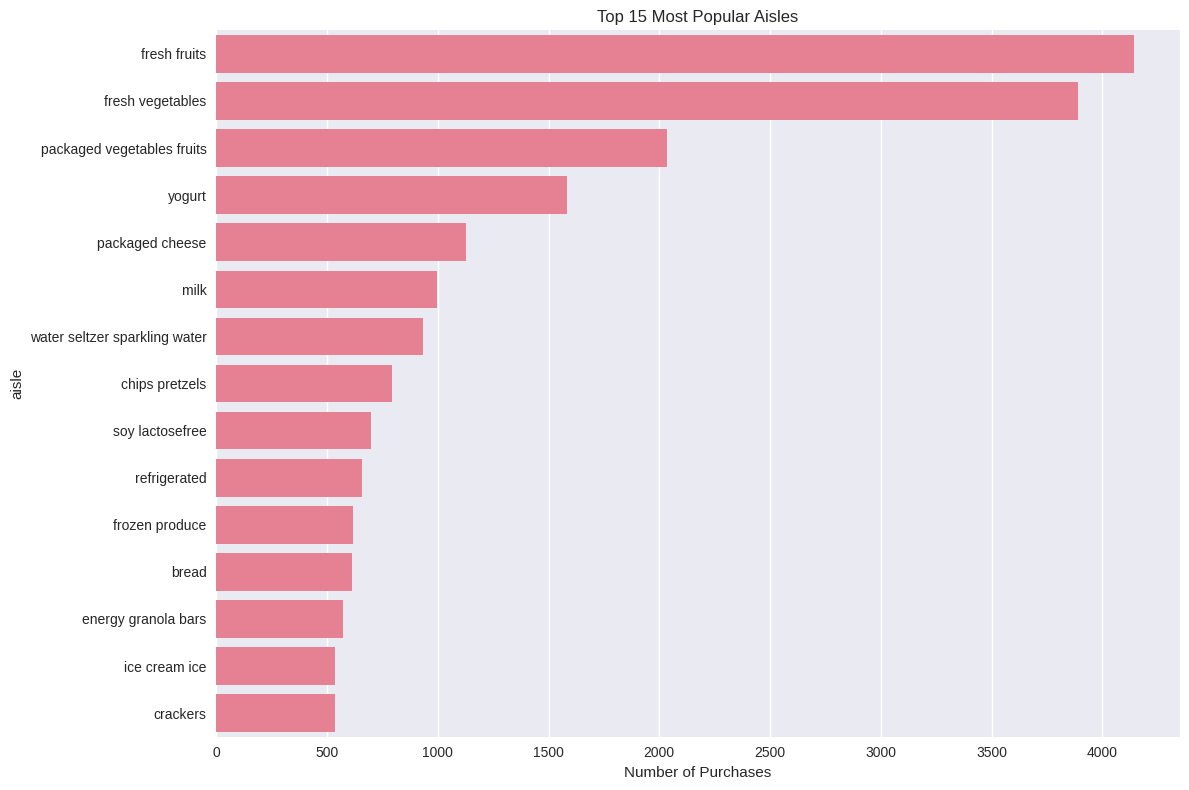

In [6]:
print("Basic Statistics:")
print(f"Number of unique customers: {sample_data['user_id'].nunique()}")
print(f"Number of unique products: {sample_data['product_id'].nunique()}")
print(f"Number of transactions: {sample_data['order_id'].nunique()}")
print(f"Time period: {sample_data['order_number'].min()} to {sample_data['order_number'].max()}")

# Products per order distribution
products_per_order = sample_data.groupby('order_id')['product_id'].count()
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(products_per_order, bins=50, edgecolor='black', alpha=0.7)
plt.title('Distribution of Products per Order')
plt.xlabel('Number of Products')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
# Top 20 most popular products
top_products = sample_data['product_name'].value_counts().head(20)
plt.barh(range(len(top_products)), top_products.values)
plt.yticks(range(len(top_products)), top_products.index)
plt.title('Top 20 Most Popular Products')
plt.xlabel('Purchase Count')
plt.tight_layout()
plt.show()

# Department distribution
plt.figure(figsize=(12, 6))
dept_counts = sample_data['department'].value_counts()
plt.pie(dept_counts.values, labels=dept_counts.index, autopct='%1.1f%%')
plt.title('Product Distribution by Department')
plt.show()

# Aisle analysis
plt.figure(figsize=(12, 8))
top_aisles = sample_data['aisle'].value_counts().head(15)
sns.barplot(x=top_aisles.values, y=top_aisles.index)
plt.title('Top 15 Most Popular Aisles')
plt.xlabel('Number of Purchases')
plt.tight_layout()
plt.show()

In [7]:
# Group products by order_id to create transactions
transactions = sample_data.groupby('order_id')['product_name'].apply(list).reset_index()

print(f"Number of transactions: {len(transactions)}")
print("Sample transactions:")
for i in range(3):
    print(f"Transaction {i+1}: {transactions['product_name'].iloc[i][:5]}...")  # Show first 5 items

# Convert to transaction format suitable for mlxtend
transaction_list = transactions['product_name'].tolist()

# Use TransactionEncoder to transform the data
te = TransactionEncoder()
te_ary = te.fit(transaction_list).transform(transaction_list)
transaction_df = pd.DataFrame(te_ary, columns=te.columns_)

print(f"Transaction matrix shape: {transaction_df.shape}")
print(f"Number of unique items: {len(transaction_df.columns)}")

# Reduce dimensionality by keeping only items with minimum support
item_freq = transaction_df.sum()
items_to_keep = item_freq[item_freq >= 50].index  # Keep items that appear at least 50 times
transaction_df_reduced = transaction_df[items_to_keep]

print(f"Reduced transaction matrix shape: {transaction_df_reduced.shape}")

Number of transactions: 3635
Sample transactions:
Transaction 1: ['Apple Cider Vinegar', 'Banana', 'Gala Apples', 'Cucumber Kirby', 'Cinnamon Raisin Granola']...
Transaction 2: ['Organic Ginger Root', 'Organic Chicken Bone Broth', 'Organic Low Sodium Chicken Cooking Stock', 'Original Soy Creamer', 'Liquid Egg Whites']...
Transaction 3: ['Organic Milk', 'Ancient Grain Blueberry Hemp Granola', 'Pure Organic Pineapple Juice', 'Bunched Cilantro', 'Organic Mint']...
Transaction matrix shape: (3635, 10025)
Number of unique items: 10025
Reduced transaction matrix shape: (3635, 74)


Generating frequent itemsets...
Number of frequent itemsets: 92

Top 10 frequent itemsets:
     support                  itemsets  length
4   0.145805                  (Banana)       1
3   0.115818  (Bag of Organic Bananas)       1
53  0.081706    (Organic Strawberries)       1
27  0.079780    (Organic Baby Spinach)       1
41  0.069601    (Organic Hass Avocado)       1
24  0.053370         (Organic Avocado)       1
22  0.048418                   (Limes)       1
70  0.047318            (Strawberries)       1
20  0.046492             (Large Lemon)       1
47  0.045117     (Organic Raspberries)       1


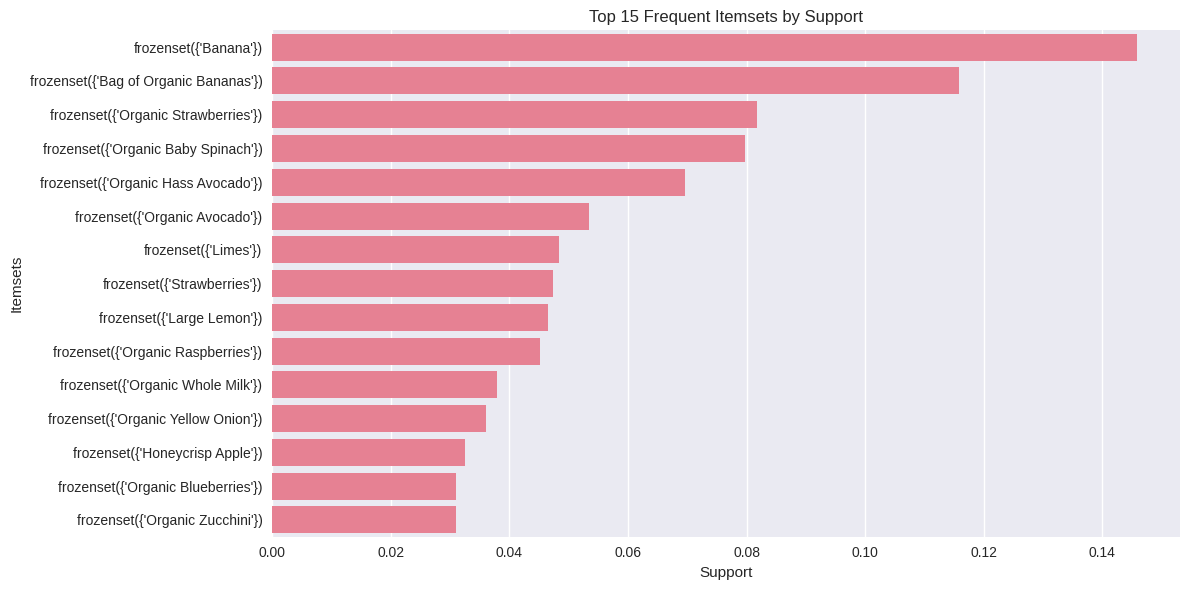

In [8]:
# Generate frequent itemsets using Apriori algorithm
print("Generating frequent itemsets...")

# Using min_support of 0.01 (1%) for demonstration
frequent_itemsets = apriori(transaction_df_reduced,
                           min_support=0.01,
                           use_colnames=True,
                           max_len=3)  # Maximum itemset size of 3

print(f"Number of frequent itemsets: {len(frequent_itemsets)}")
print("\nTop 10 frequent itemsets:")
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))
print(frequent_itemsets.sort_values('support', ascending=False).head(10))

# Visualize frequent itemsets
plt.figure(figsize=(12, 6))
top_itemsets = frequent_itemsets.nlargest(15, 'support')
sns.barplot(x='support', y=top_itemsets['itemsets'].astype(str), data=top_itemsets)
plt.title('Top 15 Frequent Itemsets by Support')
plt.xlabel('Support')
plt.ylabel('Itemsets')
plt.tight_layout()
plt.show()

In [9]:
# Generate association rules
print("Generating association rules...")

rules = association_rules(frequent_itemsets,
                         metric="confidence",
                         min_threshold=0.1)  # Minimum confidence of 10%

print(f"Number of association rules generated: {len(rules)}")

# Display top rules by different metrics
print("\nTop 10 rules by confidence:")
print(rules.nlargest(10, 'confidence')[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

print("\nTop 10 rules by lift:")
print(rules.nlargest(10, 'lift')[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

print("\nTop 10 rules by support:")
print(rules.nlargest(10, 'support')[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

Generating association rules...
Number of association rules generated: 30

Top 10 rules by confidence:
               antecedents               consequents   support  confidence  \
16    (Organic Fuji Apple)                  (Banana)  0.010729    0.371429   
8         (Cucumber Kirby)                  (Banana)  0.010729    0.354545   
9       (Honeycrisp Apple)                  (Banana)  0.010729    0.330508   
3   (Organic Hass Avocado)  (Bag of Organic Bananas)  0.021458    0.308300   
21          (Strawberries)                  (Banana)  0.014580    0.308140   
13       (Organic Avocado)                  (Banana)  0.015681    0.293814   
5    (Organic Raspberries)  (Bag of Organic Bananas)  0.012105    0.268293   
19    (Organic Whole Milk)                  (Banana)  0.010179    0.268116   
10           (Large Lemon)                  (Banana)  0.012380    0.266272   
29   (Organic Raspberries)    (Organic Strawberries)  0.011004    0.243902   

        lift  
16  2.547439  
8   2.43

In [10]:
# Filter rules for better business insights
print("Filtering rules for business relevance...")

# Filter rules with minimum confidence of 20% and lift > 1.5
filtered_rules = rules[
    (rules['confidence'] >= 0.2) &
    (rules['lift'] > 1.5) &
    (rules['support'] >= 0.005)
].copy()

print(f"Number of filtered rules: {len(filtered_rules)}")

# Add additional useful metrics
filtered_rules['antecedent_len'] = filtered_rules['antecedents'].apply(lambda x: len(x))
filtered_rules['consequent_len'] = filtered_rules['consequents'].apply(lambda x: len(x))

# Display comprehensive results
print("\nComprehensive rule analysis:")
for idx, rule in filtered_rules.nlargest(15, 'lift').iterrows():
    print(f"Rule: {set(rule['antecedents'])} -> {set(rule['consequents'])}")
    print(f"  Support: {rule['support']:.3f}, Confidence: {rule['confidence']:.3f}, Lift: {rule['lift']:.3f}")
    print()

Filtering rules for business relevance...
Number of filtered rules: 13

Comprehensive rule analysis:
Rule: {'Organic Raspberries'} -> {'Organic Strawberries'}
  Support: 0.011, Confidence: 0.244, Lift: 2.985

Rule: {'Organic Hass Avocado'} -> {'Organic Strawberries'}
  Support: 0.015, Confidence: 0.221, Lift: 2.709

Rule: {'Organic Hass Avocado'} -> {'Bag of Organic Bananas'}
  Support: 0.021, Confidence: 0.308, Lift: 2.662

Rule: {'Organic Fuji Apple'} -> {'Banana'}
  Support: 0.011, Confidence: 0.371, Lift: 2.547

Rule: {'Cucumber Kirby'} -> {'Banana'}
  Support: 0.011, Confidence: 0.355, Lift: 2.432

Rule: {'Organic Raspberries'} -> {'Bag of Organic Bananas'}
  Support: 0.012, Confidence: 0.268, Lift: 2.316

Rule: {'Honeycrisp Apple'} -> {'Banana'}
  Support: 0.011, Confidence: 0.331, Lift: 2.267

Rule: {'Strawberries'} -> {'Banana'}
  Support: 0.015, Confidence: 0.308, Lift: 2.113

Rule: {'Organic Avocado'} -> {'Banana'}
  Support: 0.016, Confidence: 0.294, Lift: 2.015

Rule: {'Org

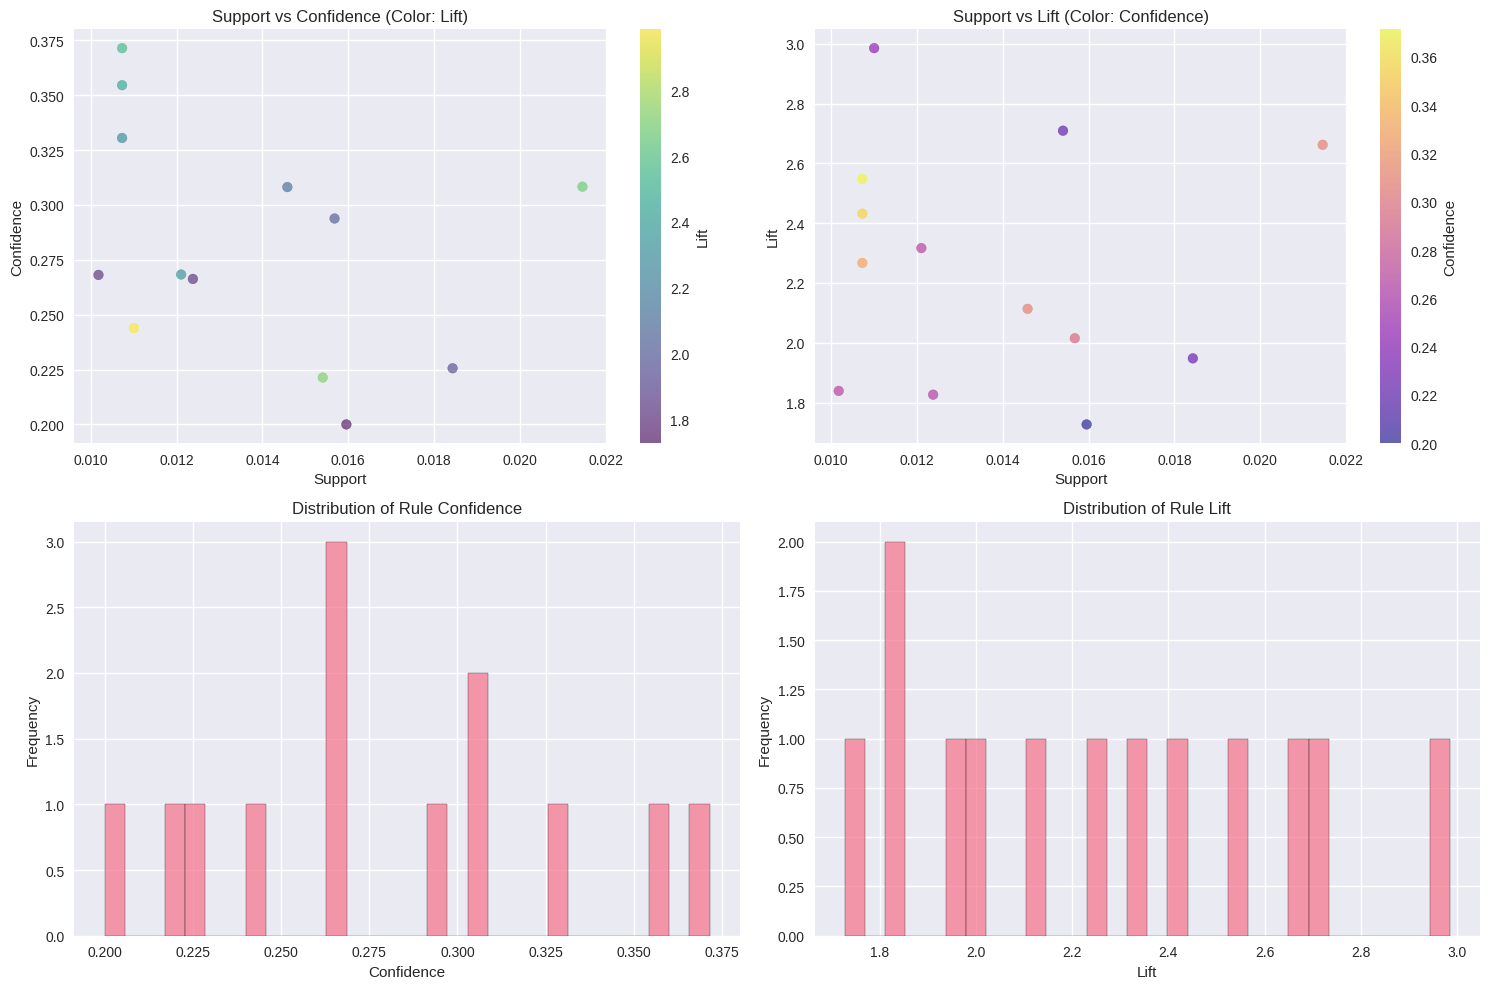

Network analysis of top rules:
Organic Raspberries --> Organic Strawberries (lift: 2.99)
Organic Hass Avocado --> Organic Strawberries (lift: 2.71)
Organic Hass Avocado --> Bag of Organic Bananas (lift: 2.66)
Organic Fuji Apple --> Banana (lift: 2.55)
Cucumber Kirby --> Banana (lift: 2.43)
Organic Raspberries --> Bag of Organic Bananas (lift: 2.32)
Honeycrisp Apple --> Banana (lift: 2.27)
Strawberries --> Banana (lift: 2.11)
Organic Avocado --> Banana (lift: 2.02)
Organic Strawberries --> Bag of Organic Bananas (lift: 1.95)
Organic Whole Milk --> Banana (lift: 1.84)
Large Lemon --> Banana (lift: 1.83)
Organic Baby Spinach --> Bag of Organic Bananas (lift: 1.73)


In [11]:
# Create visualizations for the association rules
plt.figure(figsize=(15, 10))

# Scatter plot of Support vs Confidence
plt.subplot(2, 2, 1)
plt.scatter(filtered_rules['support'], filtered_rules['confidence'], alpha=0.6, c=filtered_rules['lift'], cmap='viridis')
plt.colorbar(label='Lift')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('Support vs Confidence (Color: Lift)')

# Support vs Lift
plt.subplot(2, 2, 2)
plt.scatter(filtered_rules['support'], filtered_rules['lift'], alpha=0.6, c=filtered_rules['confidence'], cmap='plasma')
plt.colorbar(label='Confidence')
plt.xlabel('Support')
plt.ylabel('Lift')
plt.title('Support vs Lift (Color: Confidence)')

# Distribution of key metrics
plt.subplot(2, 2, 3)
plt.hist(filtered_rules['confidence'], bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Confidence')
plt.ylabel('Frequency')
plt.title('Distribution of Rule Confidence')

plt.subplot(2, 2, 4)
plt.hist(filtered_rules['lift'], bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Lift')
plt.ylabel('Frequency')
plt.title('Distribution of Rule Lift')

plt.tight_layout()
plt.show()

# Network graph of top rules (conceptual)
top_rules = filtered_rules.nlargest(20, 'lift')
print("Network analysis of top rules:")
for idx, rule in top_rules.iterrows():
    antecedents = list(rule['antecedents'])[0] if len(rule['antecedents']) == 1 else list(rule['antecedents'])
    consequents = list(rule['consequents'])[0] if len(rule['consequents']) == 1 else list(rule['consequents'])
    print(f"{antecedents} --> {consequents} (lift: {rule['lift']:.2f})")

In [12]:
# Analyze associations at department level
print("Analyzing department-level associations...")

# Create department transactions
dept_transactions = sample_data.groupby('order_id')['department'].apply(list).reset_index()
dept_transaction_list = dept_transactions['department'].tolist()

# Transform department transactions
te_dept = TransactionEncoder()
te_dept_ary = te_dept.fit(dept_transaction_list).transform(dept_transaction_list)
dept_transaction_df = pd.DataFrame(te_dept_ary, columns=te_dept.columns_)

# Generate department frequent itemsets
dept_frequent_itemsets = apriori(dept_transaction_df,
                                min_support=0.05,
                                use_colnames=True,
                                max_len=2)

# Generate department association rules
dept_rules = association_rules(dept_frequent_itemsets,
                              metric="confidence",
                              min_threshold=0.2)

print("Department-level association rules:")
for idx, rule in dept_rules.nlargest(10, 'lift').iterrows():
    print(f"Department Rule: {set(rule['antecedents'])} -> {set(rule['consequents'])}")
    print(f"  Support: {rule['support']:.3f}, Confidence: {rule['confidence']:.3f}, Lift: {rule['lift']:.3f}")

Analyzing department-level associations...
Department-level association rules:
Department Rule: {'canned goods'} -> {'dry goods pasta'}
  Support: 0.077, Confidence: 0.359, Lift: 1.787
Department Rule: {'dry goods pasta'} -> {'canned goods'}
  Support: 0.077, Confidence: 0.384, Lift: 1.787
Department Rule: {'dry goods pasta'} -> {'meat seafood'}
  Support: 0.063, Confidence: 0.312, Lift: 1.629
Department Rule: {'meat seafood'} -> {'dry goods pasta'}
  Support: 0.063, Confidence: 0.328, Lift: 1.629
Department Rule: {'meat seafood'} -> {'canned goods'}
  Support: 0.063, Confidence: 0.329, Lift: 1.529
Department Rule: {'canned goods'} -> {'meat seafood'}
  Support: 0.063, Confidence: 0.293, Lift: 1.529
Department Rule: {'dry goods pasta'} -> {'bakery'}
  Support: 0.084, Confidence: 0.419, Lift: 1.525
Department Rule: {'bakery'} -> {'dry goods pasta'}
  Support: 0.084, Confidence: 0.307, Lift: 1.525
Department Rule: {'breakfast'} -> {'canned goods'}
  Support: 0.052, Confidence: 0.318, Lif

In [14]:
# Generate business recommendations based on the analysis
print("="*80)
print("BUSINESS RECOMMENDATIONS FOR FRESHMART GROCERIES")
print("="*80)

# Categorize rules for different business applications
high_confidence_rules = filtered_rules[filtered_rules['confidence'] > 0.3]
high_lift_rules = filtered_rules[filtered_rules['lift'] > 3]
high_support_rules = filtered_rules[filtered_rules['support'] > 0.01]

print("\n1. HIGH-CONFIDENCE RULES (Reliable Cross-Selling Opportunities):")
print("   Use for 'Frequently Bought Together' recommendations")
for idx, rule in high_confidence_rules.nlargest(10, 'confidence').iterrows():
    antecedents = list(rule['antecedents'])
    consequents = list(rule['consequents'])
    print(f"   • When customers buy {antecedents[0]}, recommend {consequents[0]}")
    print(f"     (Confidence: {rule['confidence']:.1%}, Lift: {rule['lift']:.2f})")

print("\n2. HIGH-LIFT RULES (Synergistic Product Pairs):")
print("   Use for strategic product bundling and promotions")
for idx, rule in high_lift_rules.nlargest(10, 'lift').iterrows():
    antecedents = list(rule['antecedents'])
    consequents = list(rule['consequents'])
    print(f"   • Bundle: {antecedents[0]} + {consequents[0]}")
    print(f"     (Customers are {rule['lift']:.1f}x more likely to buy together)")

print("\n3. HIGH-SUPPORT RULES (Popular Combinations):")
print("   Use for creating popular meal kits and bundles")
for idx, rule in high_support_rules.nlargest(10, 'support').iterrows():
    antecedents = list(rule['antecedents'])
    consequents = list(rule['consequents'])
    print(f"   • Popular combo: {antecedents[0]} → {consequents[0]}")
    print(f"     (Appears in {rule['support']:.1%} of all transactions)")

# Department-level recommendations
print("\n4. DEPARTMENT-LEVEL STRATEGIES:")
print("   Optimize store layout and category management")
for idx, rule in dept_rules.nlargest(5, 'lift').iterrows():
    antecedents = list(rule['antecedents'])
    consequents = list(rule['consequents'])
    print(f"   • Place {antecedents[0]} department near {consequents[0]} department")
    print(f"     (Lift: {rule['lift']:.2f}, Confidence: {rule['confidence']:.1%})")



BUSINESS RECOMMENDATIONS FOR FRESHMART GROCERIES

1. HIGH-CONFIDENCE RULES (Reliable Cross-Selling Opportunities):
   Use for 'Frequently Bought Together' recommendations
   • When customers buy Organic Fuji Apple, recommend Banana
     (Confidence: 37.1%, Lift: 2.55)
   • When customers buy Cucumber Kirby, recommend Banana
     (Confidence: 35.5%, Lift: 2.43)
   • When customers buy Honeycrisp Apple, recommend Banana
     (Confidence: 33.1%, Lift: 2.27)
   • When customers buy Organic Hass Avocado, recommend Bag of Organic Bananas
     (Confidence: 30.8%, Lift: 2.66)
   • When customers buy Strawberries, recommend Banana
     (Confidence: 30.8%, Lift: 2.11)

2. HIGH-LIFT RULES (Synergistic Product Pairs):
   Use for strategic product bundling and promotions

3. HIGH-SUPPORT RULES (Popular Combinations):
   Use for creating popular meal kits and bundles
   • Popular combo: Organic Hass Avocado → Bag of Organic Bananas
     (Appears in 2.1% of all transactions)
   • Popular combo: Organ